# EDA & Tiền xử lý dữ liệu — Melbourne Housing

Notebook khảo sát và tiền xử lý `melb_data.csv` (13.580 dòng × 21 cột) theo luồng **clean-first**:
kiểm tra dữ liệu → phân phối đơn biến → cardinality → phát hiện & xử lý outlier →
xử lý missing (so sánh random sampling vs KNN) → quan hệ với target `Price`.

Mỗi bước gồm phần **Lý do** (vì sao chọn cách làm) và **Phân tích** (kết quả thật nói lên điều gì).


## 0. Thiết lập môi trường

Mount Google Drive và đặt thư mục làm việc để đọc `melb_data.csv`.

In [3]:
from google.cloud import bigquery
from google.colab import auth, drive
import os
# Mount to Google Drive if data on Drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/AIO-Conquer02')
os.getcwd()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/MyDrive/AIO-Conquer02'

## 1. Nạp & kiểm tra tổng quan dữ liệu

**Lý do:** Trước mọi phân tích cần `df.info()` để nắm: số dòng/cột, kiểu dữ liệu từng cột,
và mức độ đầy đủ (non-null). Đây là căn cứ để biết cột nào thiếu dữ liệu và cột nào là số / phân loại.

In [4]:
import pandas as pd
df = pd.read_csv('melb_data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

> 📊 **Phân tích:** Dataset có **13.580 dòng × 21 cột** (13 cột số, 8 cột `object`). 4 cột thiếu dữ liệu: **`BuildingArea` thiếu 6.450 (~47%)**, **`YearBuilt` thiếu 5.375 (~40%)**, `CouncilArea` thiếu 1.369 (~10%), `Car` thiếu 62 (~0,5%). Hai cột BuildingArea/YearBuilt thiếu rất nặng → không thể bỏ dòng, cần chiến lược điền cẩn thận. `Postcode` tuy kiểu số nhưng thực chất là mã định danh.

### Xem mẫu dữ liệu

**Lý do:** Xem vài dòng đầu để hiểu định dạng giá trị thực tế của từng cột (đơn vị, kiểu chuỗi/số, ví dụ giá trị).

In [5]:
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


> 📊 **Phân tích:** Mỗi dòng là một giao dịch nhà; `Price` là target (đơn vị đô, cỡ hàng triệu). `Type` (h/u/t), `Method` (S/SP/PI/VB…) là phân loại; `Date` dạng chuỗi `d/m/Y` (chưa parse); `Address` gần như duy nhất từng dòng; `Lattitude/Longtitude` mã hoá vị trí. Thấy ngay `BuildingArea`/`YearBuilt` có `NaN` ngay ở vài dòng đầu.

## 2. Phân phối đơn biến

**Lý do:** Khảo sát phân phối từng biến. Dùng **histogram** cho biến số (thấy hình dạng, độ lệch,
khoảng giá trị) và **bar chart** `value_counts` cho biến phân loại (thấy tần suất từng nhóm). Với cột
phân loại cardinality cao chỉ lấy **top-20** để biểu đồ còn đọc được. Dùng dữ liệu **thật** (chưa xử lý)
để phản ánh đúng hiện trạng.

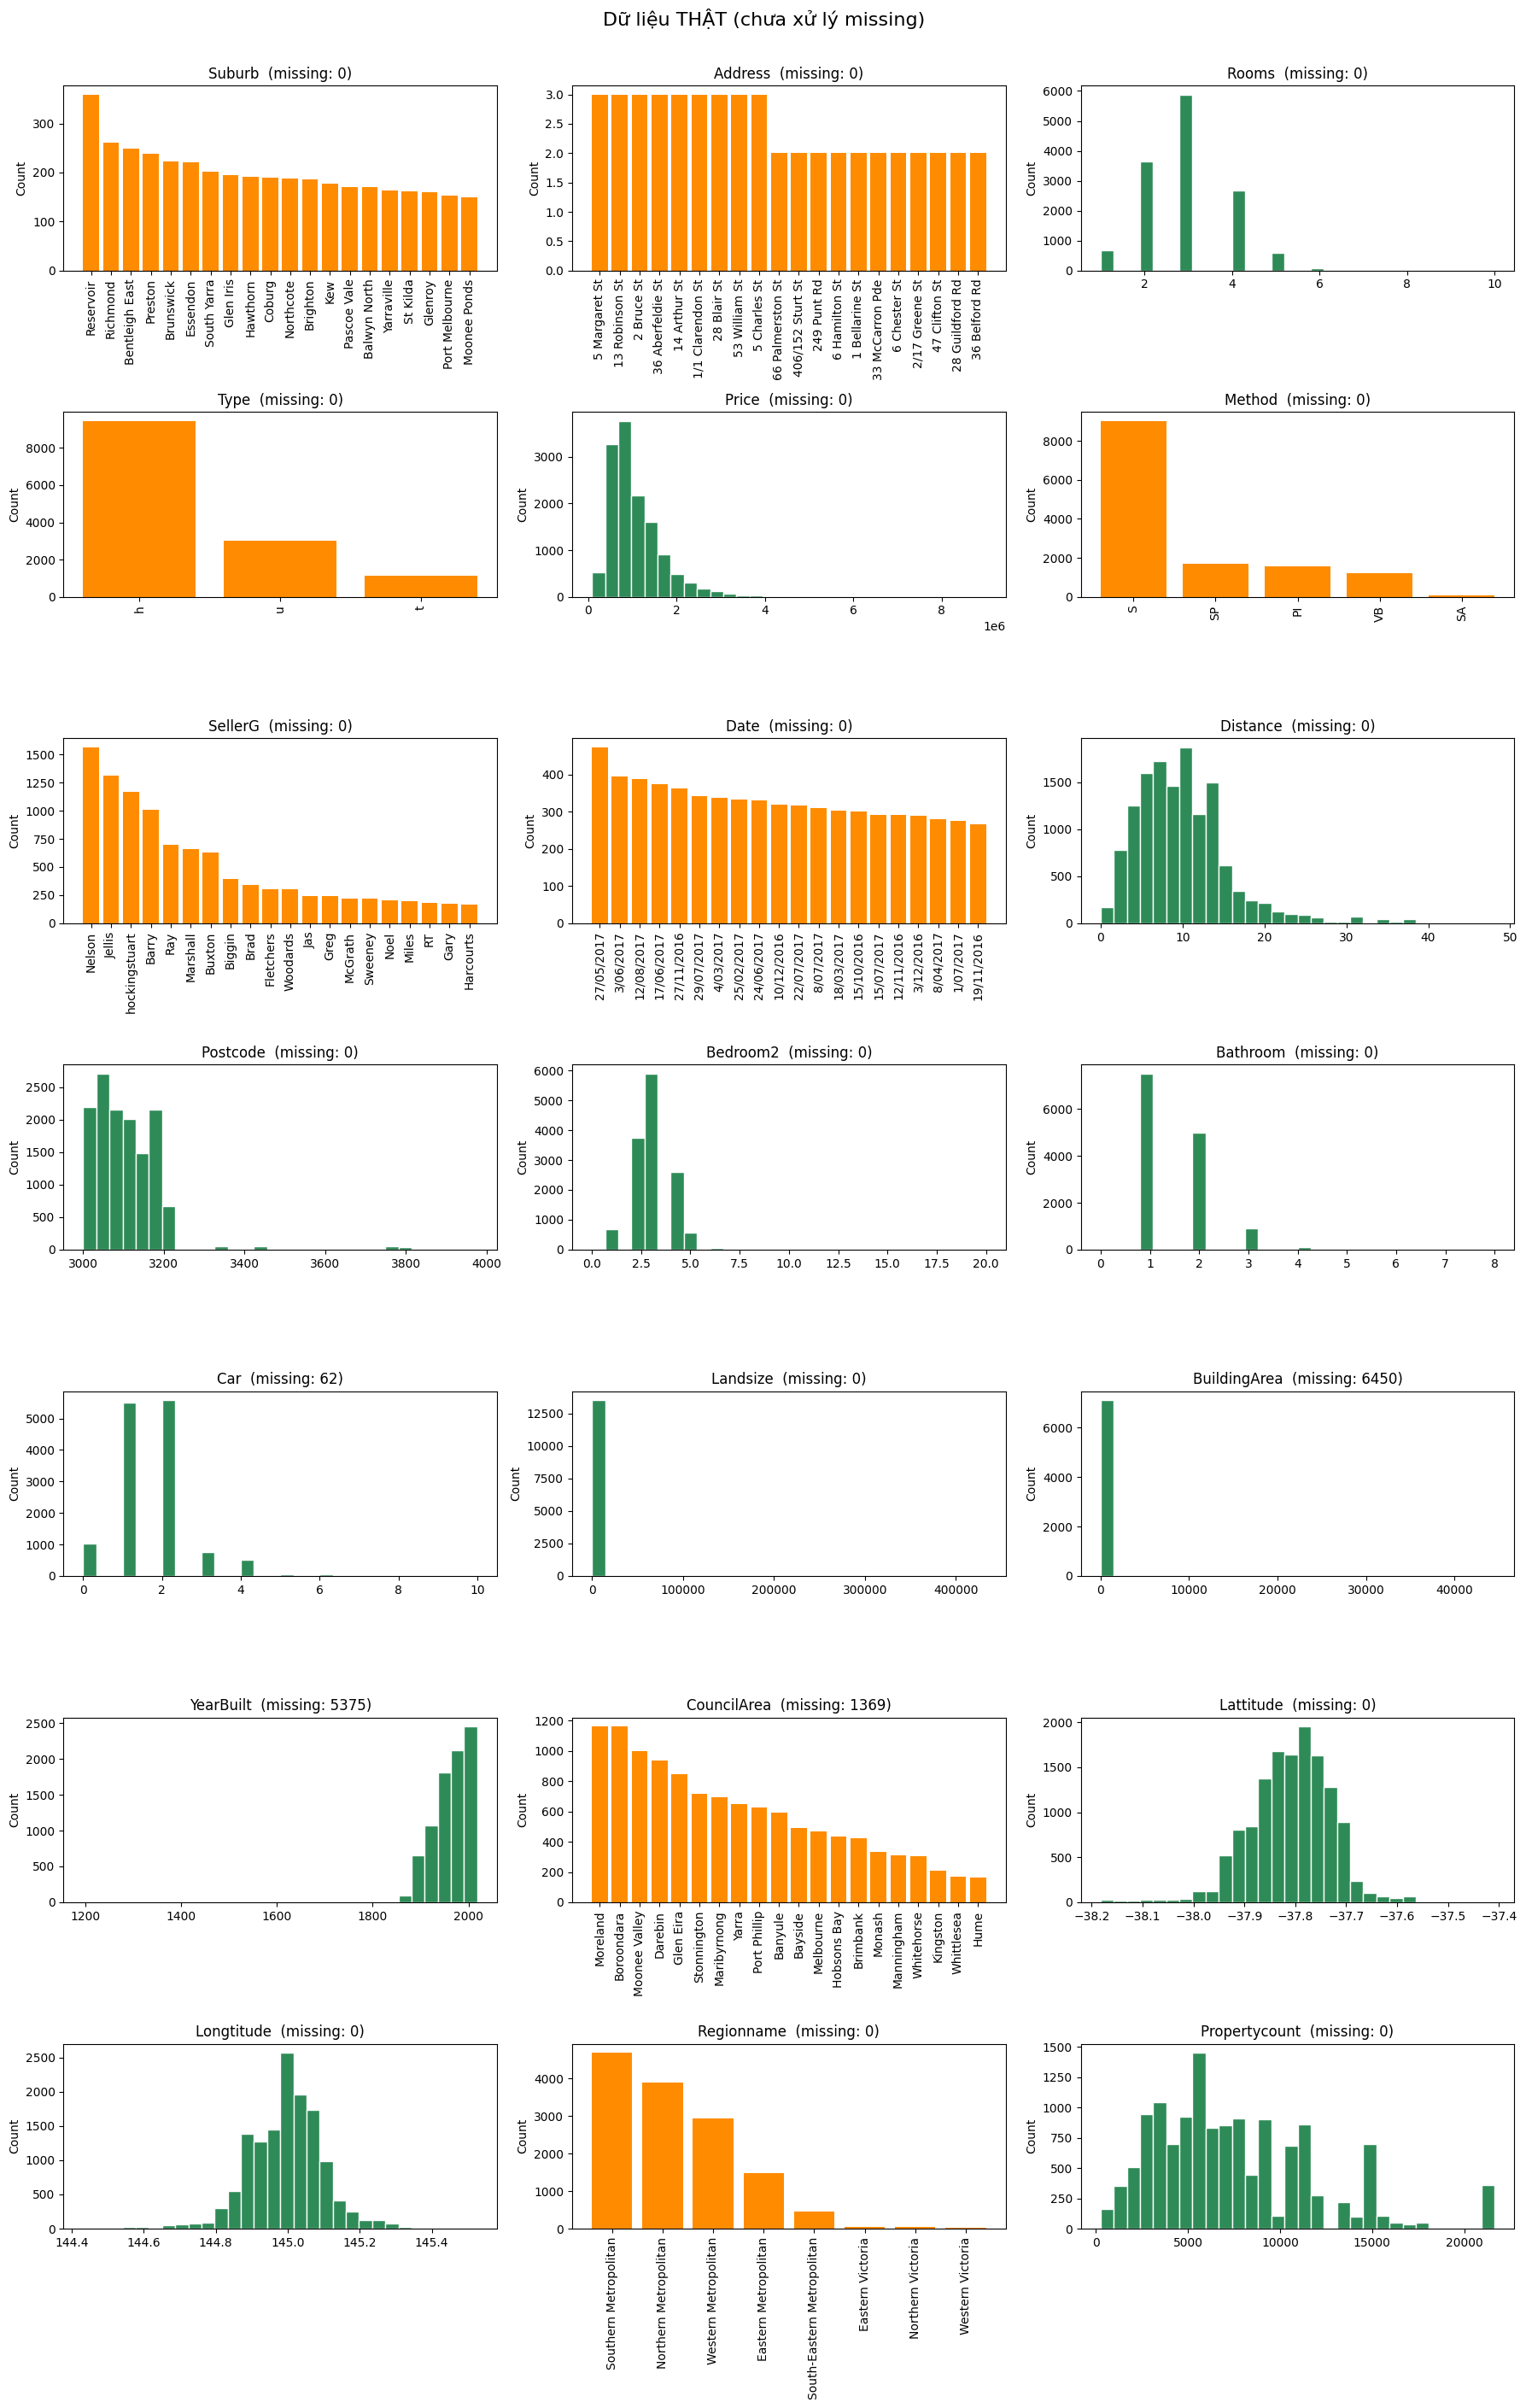

In [6]:
# ===== BẢN 1: Dữ liệu THẬT (chỉ giá trị non-null, không điền missing) =====
import matplotlib.pyplot as plt
import numpy as np

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

cols = df.columns.tolist()
n = len(cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    n_missing = df[col].isna().sum()
    if col in numeric_cols:
        # Cột số -> chỉ vẽ giá trị thật (dropna), không điền
        ax.hist(df[col].dropna(), bins=30, color='seagreen', edgecolor='white')
        ax.set_ylabel('Count')
    else:
        # Cột phân loại -> bar chart đếm số lượng (top 20)
        vc = df[col].value_counts().head(20)
        ax.bar(vc.index.astype(str), vc.values, color='darkorange')
        ax.tick_params(axis='x', rotation=90)
        ax.set_ylabel('Count')
    # Ghi rõ số lượng missing để dễ đối chiếu với bản đã điền
    ax.set_title(f"{col}  (missing: {n_missing})")

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Dữ liệu THẬT (chưa xử lý missing)", fontsize=16, y=1.005)
plt.tight_layout()
plt.show()

> 📊 **Phân tích:** Các biến số lệch phải mạnh: **`Price`, `Landsize`, `BuildingArea`** dồn về trái với đuôi dài (do vài giá trị cực lớn). `Rooms/Bedroom2/Bathroom/Car` là biến đếm rời rạc, tập trung ở giá trị nhỏ. `YearBuilt` lệch trái (đa số nhà gần đây) kèm giá trị cực thấp bất thường. Biến phân loại **mất cân bằng nặng**: `Type` chủ yếu là 'h'; `Regionname`/`Method` dồn vào vài nhóm; `Suburb/SellerG/Address` rất nhiều giá trị (top-20 mỗi cột chỉ chiếm phần nhỏ). → gợi ý log-transform cho biến lệch và lưu ý cardinality khi encode.

## 3. Cardinality của biến phân loại

**Lý do:** Đếm số giá trị duy nhất (`nunique`) và số missing của từng biến phân loại để đánh giá
**cardinality** — căn cứ chọn chiến lược encoding sau này (cardinality thấp → one-hot; cao → frequency/target encoding).

In [7]:
# ===== Số lượng unique values của các category feature =====
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

unique_summary = (
    df[categorical_cols]
    .agg(['nunique'])
    .T
    .rename(columns={'nunique': 'n_unique'})
)
unique_summary['n_missing'] = df[categorical_cols].isna().sum()
unique_summary = unique_summary.sort_values('n_unique', ascending=False)

print(unique_summary)

             n_unique  n_missing
Address         13378          0
Suburb            314          0
SellerG           268          0
Date               58          0
CouncilArea        33       1369
Regionname          8          0
Method              5          0
Type                3          0


> 📊 **Phân tích:** Cardinality chênh lệch rất lớn: **`Address` 13.378** (≈ số dòng → gần như unique, vô dụng nếu encode trực tiếp → nên bỏ), **`Suburb` 314**, **`SellerG` 268** (cao → frequency/target encoding), `CouncilArea` 33 (kèm 1.369 missing), `Date` 58 (nên tách year/month). Cardinality thấp hợp **one-hot**: `Regionname` 8, `Method` 5, **`Type` 3**. Đây là căn cứ chính cho kế hoạch encoding.

## 4. Phát hiện outlier — Boxplot

**Lý do:** Boxplot cho từng biến số: hộp thể hiện IQR (Q1–Q3), râu tới 1.5·IQR, điểm ngoài râu được
**tự đánh dấu là outlier**. Dùng dữ liệu **thật** vì sau khi impute (KNN) outlier bị kéo về trung tâm, sẽ bị che mất.

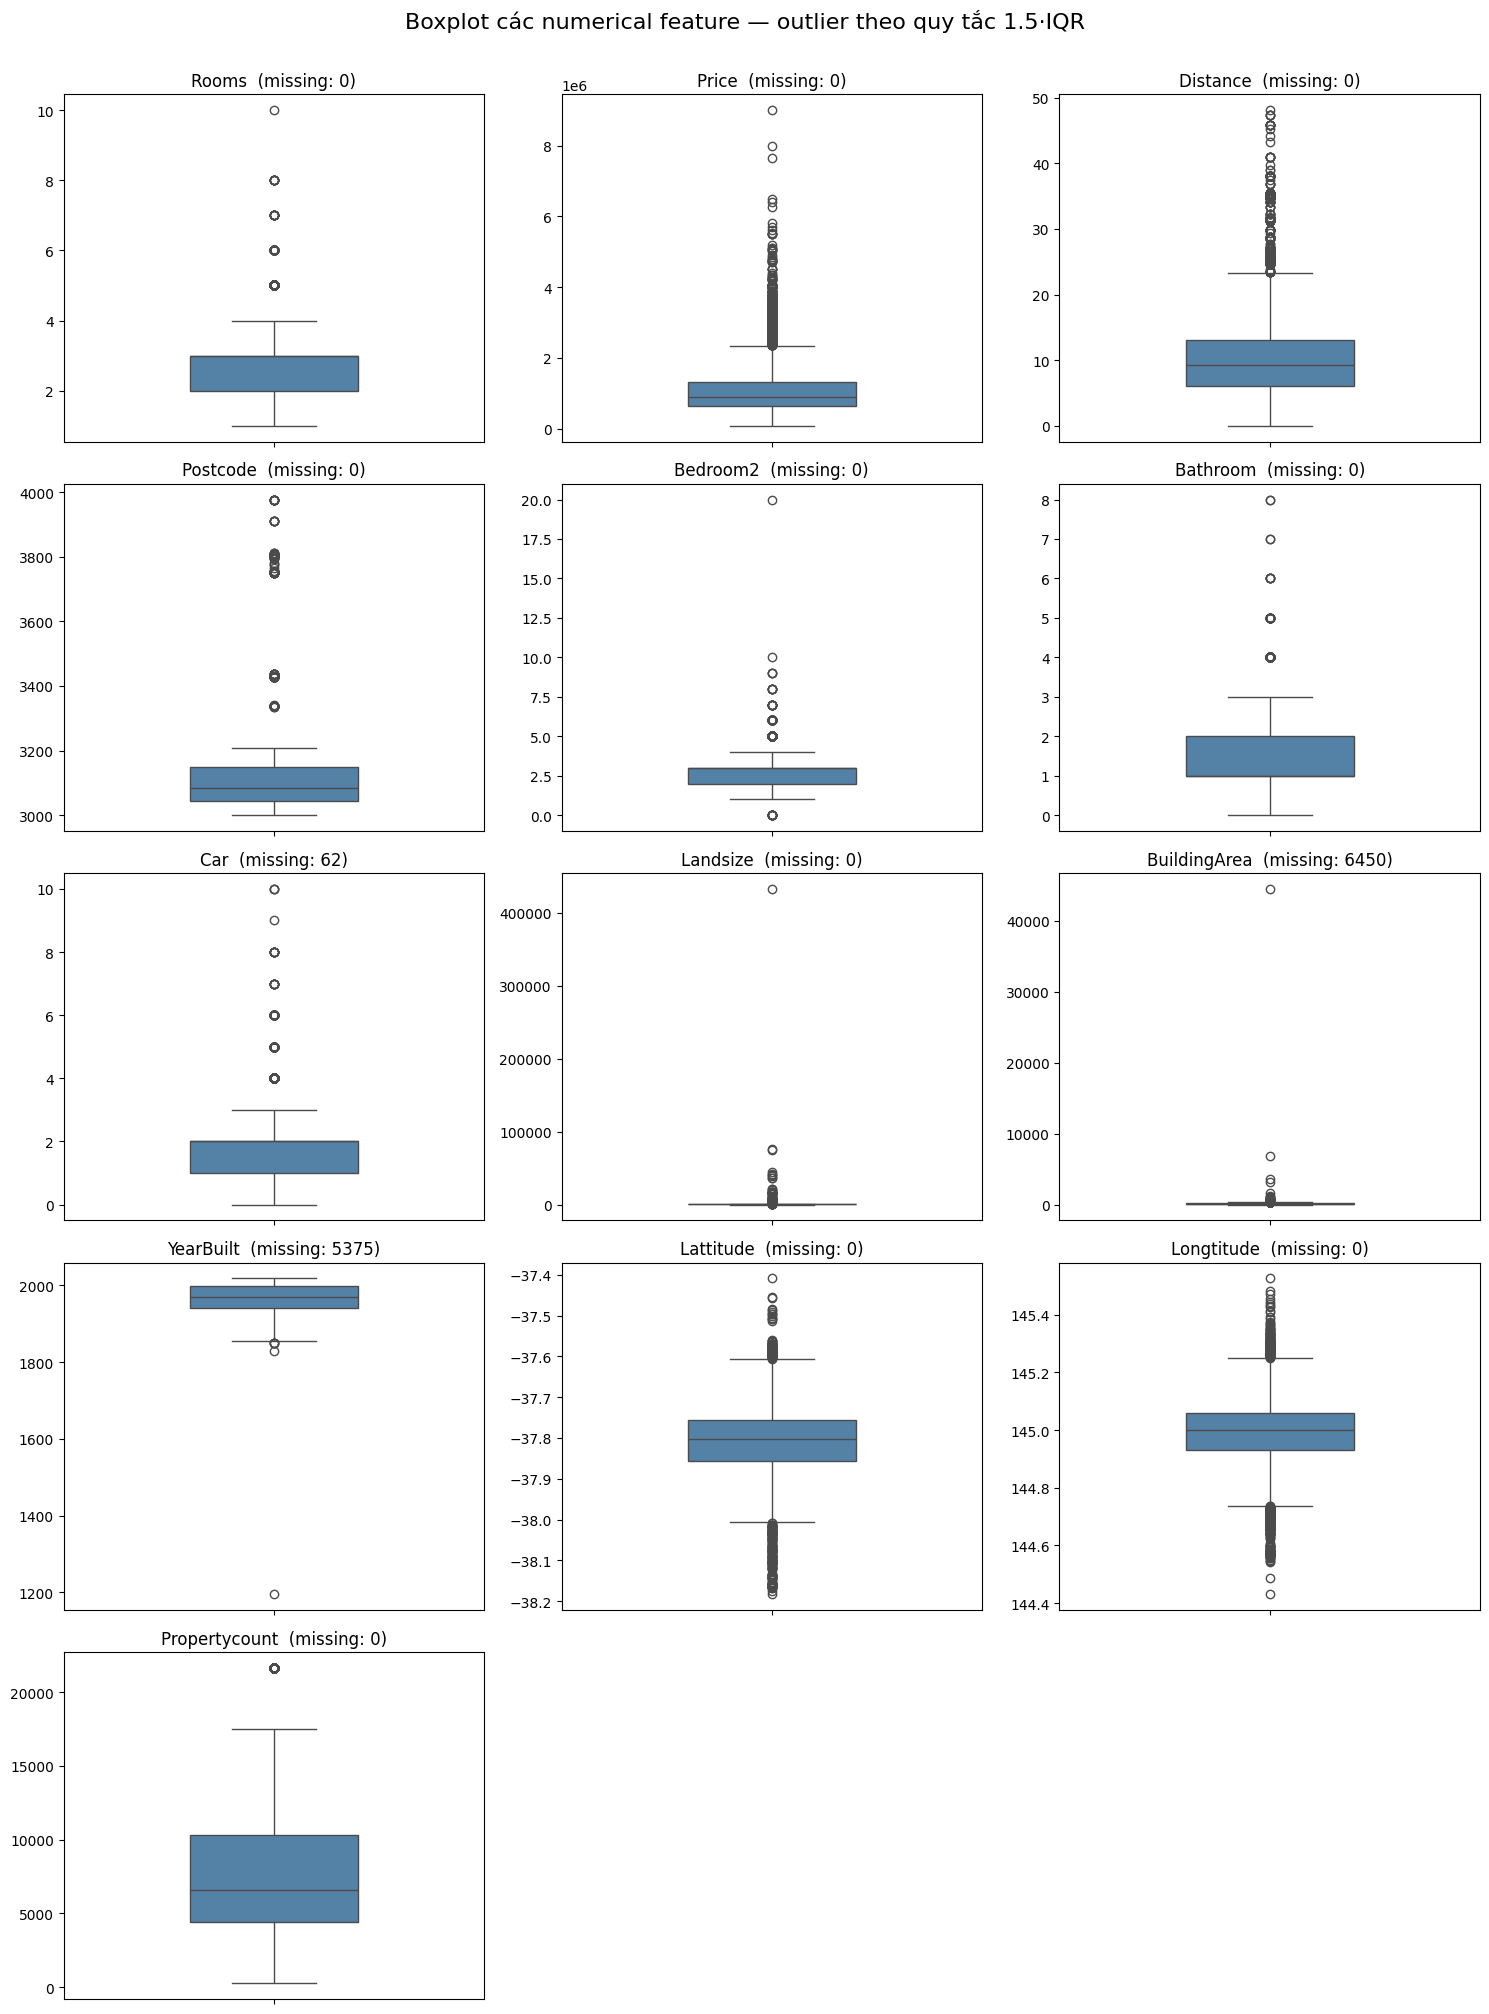

In [8]:
# ===== Boxplot cho các numerical feature (dữ liệu THẬT, để soi outlier) =====
import seaborn as sns

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes = np.array(axes).flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    # dropna: chỉ vẽ giá trị thật, không tính missing
    sns.boxplot(y=df[col].dropna(), ax=ax, color='steelblue', width=0.4)
    n_missing = df[col].isna().sum()
    ax.set_title(f"{col}  (missing: {n_missing})")
    ax.set_ylabel("")

# Ẩn ô thừa
for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplot các numerical feature — outlier theo quy tắc 1.5·IQR", fontsize=16, y=1.005)
plt.tight_layout()
plt.show()

> 📊 **Phân tích:** Hầu hết biến số có outlier theo 1.5·IQR. Dấu hiệu **lỗi/cực trị rõ**: `Landsize` có điểm ~**430.000 m²**, `BuildingArea` ~**44.500 m²**, `YearBuilt` có điểm ~**1196** (phi lý), `Bedroom2` có điểm **20**. `Price` lệch phải mạnh, nhiều outlier từ ~2,3 triệu tới 9 triệu (nhà đắt — **giá trị thật**). `Distance/Lat/Long` có outlier hai đuôi; `Rooms/Bathroom/Car` outlier chỉ là giá trị lớn hiếm. → cần phân biệt **lỗi dữ liệu** với **giá trị thật hiếm**.

## 5. Outlier theo ngữ cảnh — Scatter vs Price

**Lý do:** Scatter từng feature với `Price` để soi outlier **đa biến** mà boxplot đơn biến bỏ sót
(một điểm có thể bình thường ở từng biến nhưng bất thường ở *quan hệ* với Price), và để phân biệt
**lỗi dữ liệu** với **giá trị hiếm thật**. Dùng `alpha` thấp để chống chồng điểm (13.580 điểm).

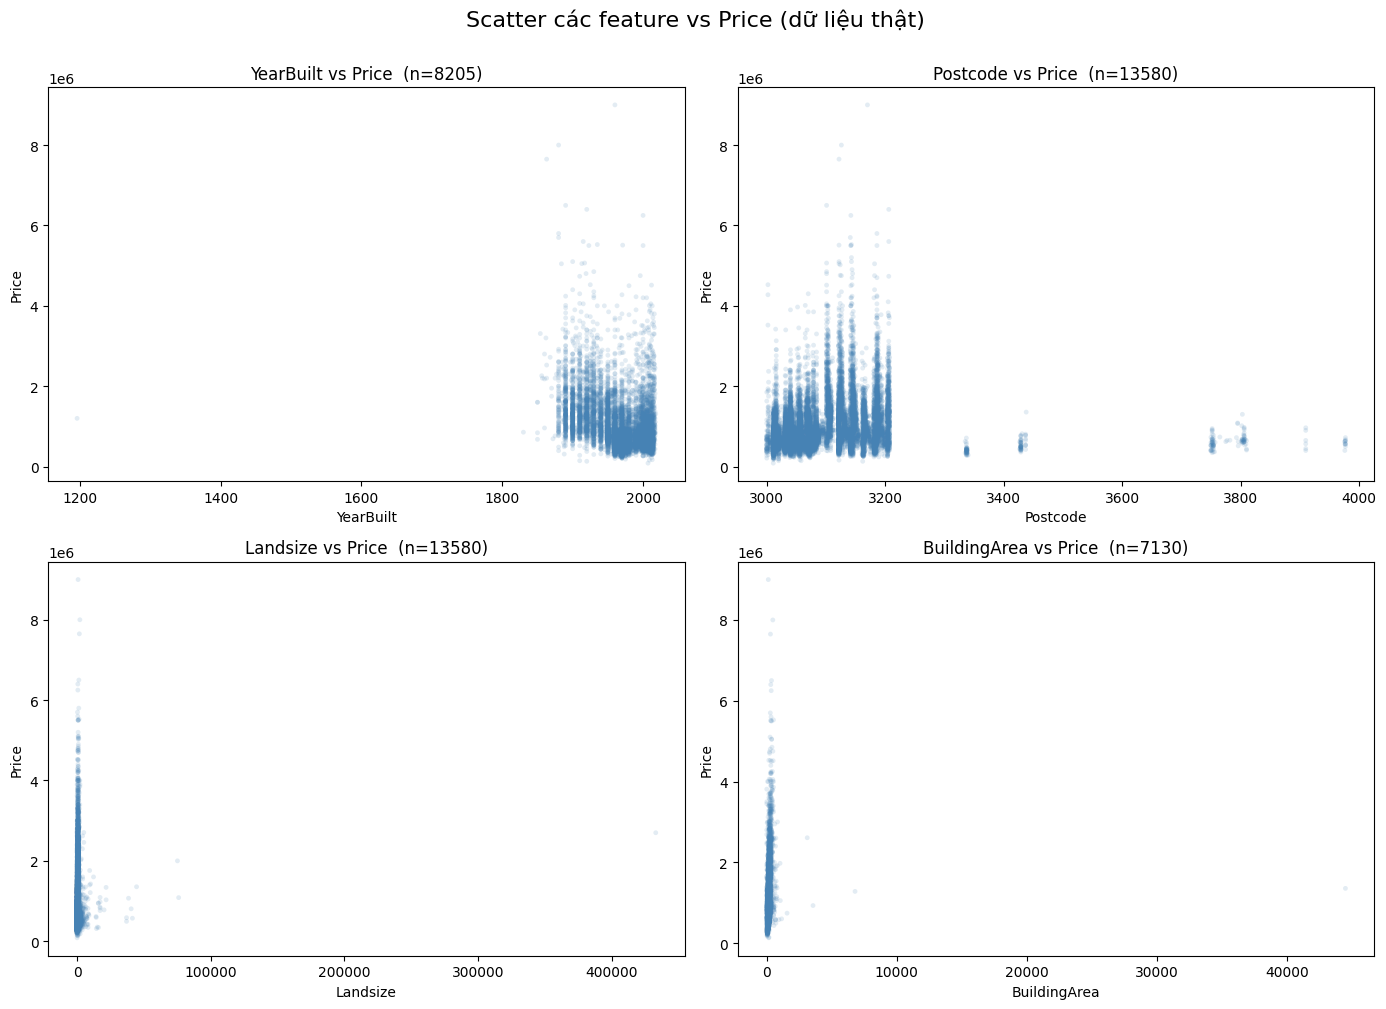

In [9]:
# ===== Scatter plot: YearBuilt / Postcode / Landsize / BuildingArea vs Price =====
features = ['YearBuilt', 'Postcode', 'Landsize', 'BuildingArea']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, features):
    # Bỏ các dòng thiếu ở col hoặc Price để vẽ
    sub = df[[col, 'Price']].dropna()
    ax.scatter(sub[col], sub['Price'], alpha=0.15, s=12, color='steelblue', edgecolors='none')
    ax.set_xlabel(col)
    ax.set_ylabel('Price')
    ax.set_title(f"{col} vs Price  (n={len(sub)})")

plt.suptitle("Scatter các feature vs Price (dữ liệu thật)", fontsize=16, y=1.005)
plt.tight_layout()
plt.show()

> 📊 **Phân tích:** **YearBuilt vs Price**: một điểm cô lập ở ~1196 tách hẳn khỏi cụm 1850–2020 → **lỗi nhập liệu** rõ ràng. **Postcode vs Price**: dữ liệu thành các vạch dọc rời rạc (cụm chính 3000–3210, vài cụm thưa giá thấp ở 3340/3430/3750–3980) → khẳng định Postcode là **mã định danh**, không phải biến liên tục. **Landsize/BuildingArea vs Price**: dạng chữ L — gần như toàn bộ điểm dồn sát 0, vài điểm cực lớn (~430k / ~44,5k) kéo giãn trục và **che mất** quan hệ thật → cần loại cực trị + log.

## 6. Xử lý outlier — Loại cực trị + Log transform

**Lý do:**
1. **Loại giá trị phi lý / cực trị**: YearBuilt ngoài [1800, 2018]; Landsize/BuildingArea ≤ 0 hoặc vượt percentile 99.
2. **Log transform** (`log1p`) cho Landsize/BuildingArea vì chúng là đại lượng độ-lớn dương, lệch phải mạnh —
   log nén đuôi, đưa phân phối về gần đối xứng.
3. **Không** log YearBuilt vì là mốc năm (log của năm vô nghĩa); nếu cần nên đổi sang tuổi nhà `2018 - YearBuilt`.

Landsize: loại bỏ 2075 giá trị (<=0 hoặc > P99=2,960)
BuildingArea: loại bỏ 89 giá trị (<=0 hoặc > P99=466)


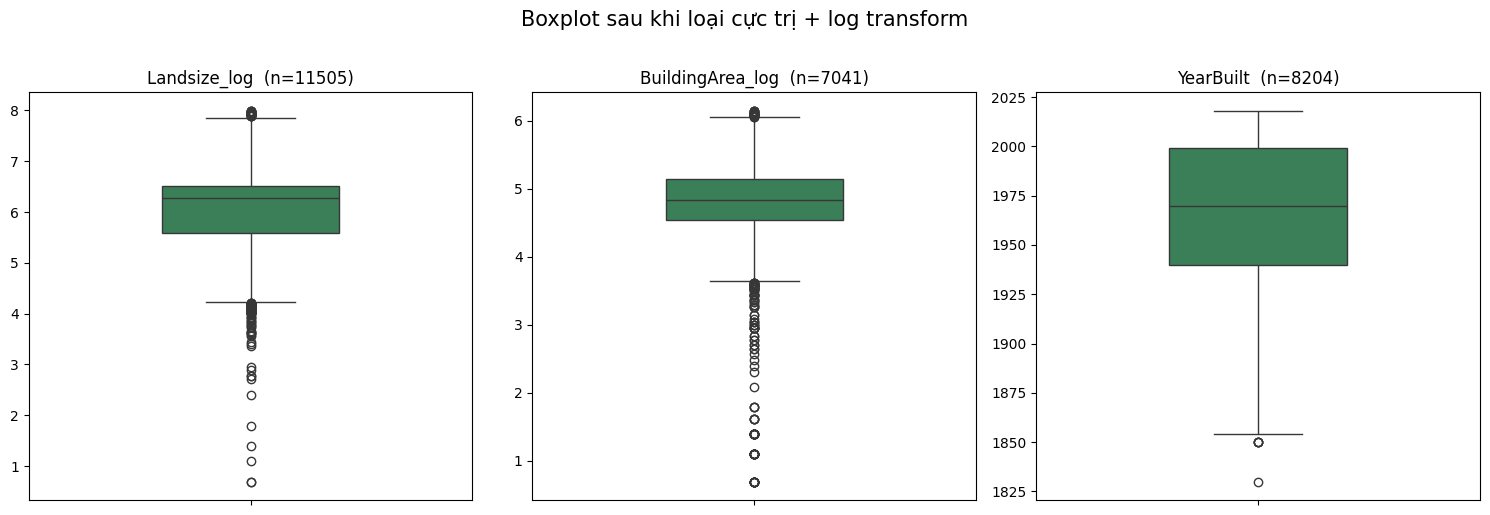

In [10]:
# ===== Loại bỏ giá trị cực trị + log transform cho Landsize / BuildingArea / YearBuilt =====
df_trans = df.copy()

# --- 1) Loại bỏ những giá trị đặc biệt (cực trị / phi lý) -> đặt thành NaN ---
# YearBuilt: năm phi lý (vd 1196, hoặc năm tương lai). Giữ khoảng hợp lý [1800, 2018].
bad_year = (df_trans['YearBuilt'] < 1800) | (df_trans['YearBuilt'] > 2018)
df_trans.loc[bad_year, 'YearBuilt'] = np.nan

# Landsize & BuildingArea: bỏ giá trị <= 0 (vô nghĩa) và phần đuôi cực trị (> percentile 99).
for col in ['Landsize', 'BuildingArea']:
    upper = df[col].quantile(0.99)
    mask = (df_trans[col] <= 0) | (df_trans[col] > upper)
    print(f"{col}: loại bỏ {mask.sum()} giá trị (<=0 hoặc > P99={upper:,.0f})")
    df_trans.loc[mask, col] = np.nan

# --- 2) Log transform cho Landsize, BuildingArea (lệch phải, là độ lớn dương) ---
df_trans['Landsize_log'] = np.log1p(df_trans['Landsize'])
df_trans['BuildingArea_log'] = np.log1p(df_trans['BuildingArea'])

# Lưu ý: KHÔNG log YearBuilt (xem giải thích). Chỉ giữ bản đã làm sạch giá trị phi lý.

# --- 3) Boxplot lại 3 feature sau khi xử lý ---
import seaborn as sns
plot_cols = ['Landsize_log', 'BuildingArea_log', 'YearBuilt']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, plot_cols):
    sns.boxplot(y=df_trans[col].dropna(), ax=ax, color='seagreen', width=0.4)
    ax.set_title(f"{col}  (n={df_trans[col].notna().sum()})")
    ax.set_ylabel("")

plt.suptitle("Boxplot sau khi loại cực trị + log transform", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

> 📊 **Phân tích:** Đã loại **2.075** giá trị `Landsize` (≤0 hoặc > P99 = 2.960) và **89** giá trị `BuildingArea` (≤0 hoặc > P99 = 466); `YearBuilt` chỉ loại **1** giá trị phi lý (1196). Sau **log transform**: `Landsize_log` (n=11.505) và `BuildingArea_log` (n=7.041) chuyển từ lệch phải cực mạnh sang **gần đối xứng** (hộp rõ, median ~6,2 và ~4,85), chỉ còn ít outlier đuôi dưới (lô/nhà rất nhỏ). `YearBuilt` (n=8.204) gọn trong [~1850, 2018], median ~1970. → biến đổi thành công, phù hợp hơn cho mô hình tuyến tính.

## 7. Điền missing (cách 1) — Random sampling

**Lý do:** Lấy mẫu ngẫu nhiên từ các giá trị non-null đã có của chính cột đó. Ưu điểm: giữ đúng
**phân phối biên** của từng cột, không tạo spike như `fillna(mean)`. Vẽ lại histogram để kiểm tra
hình dạng phân phối có được bảo toàn không.

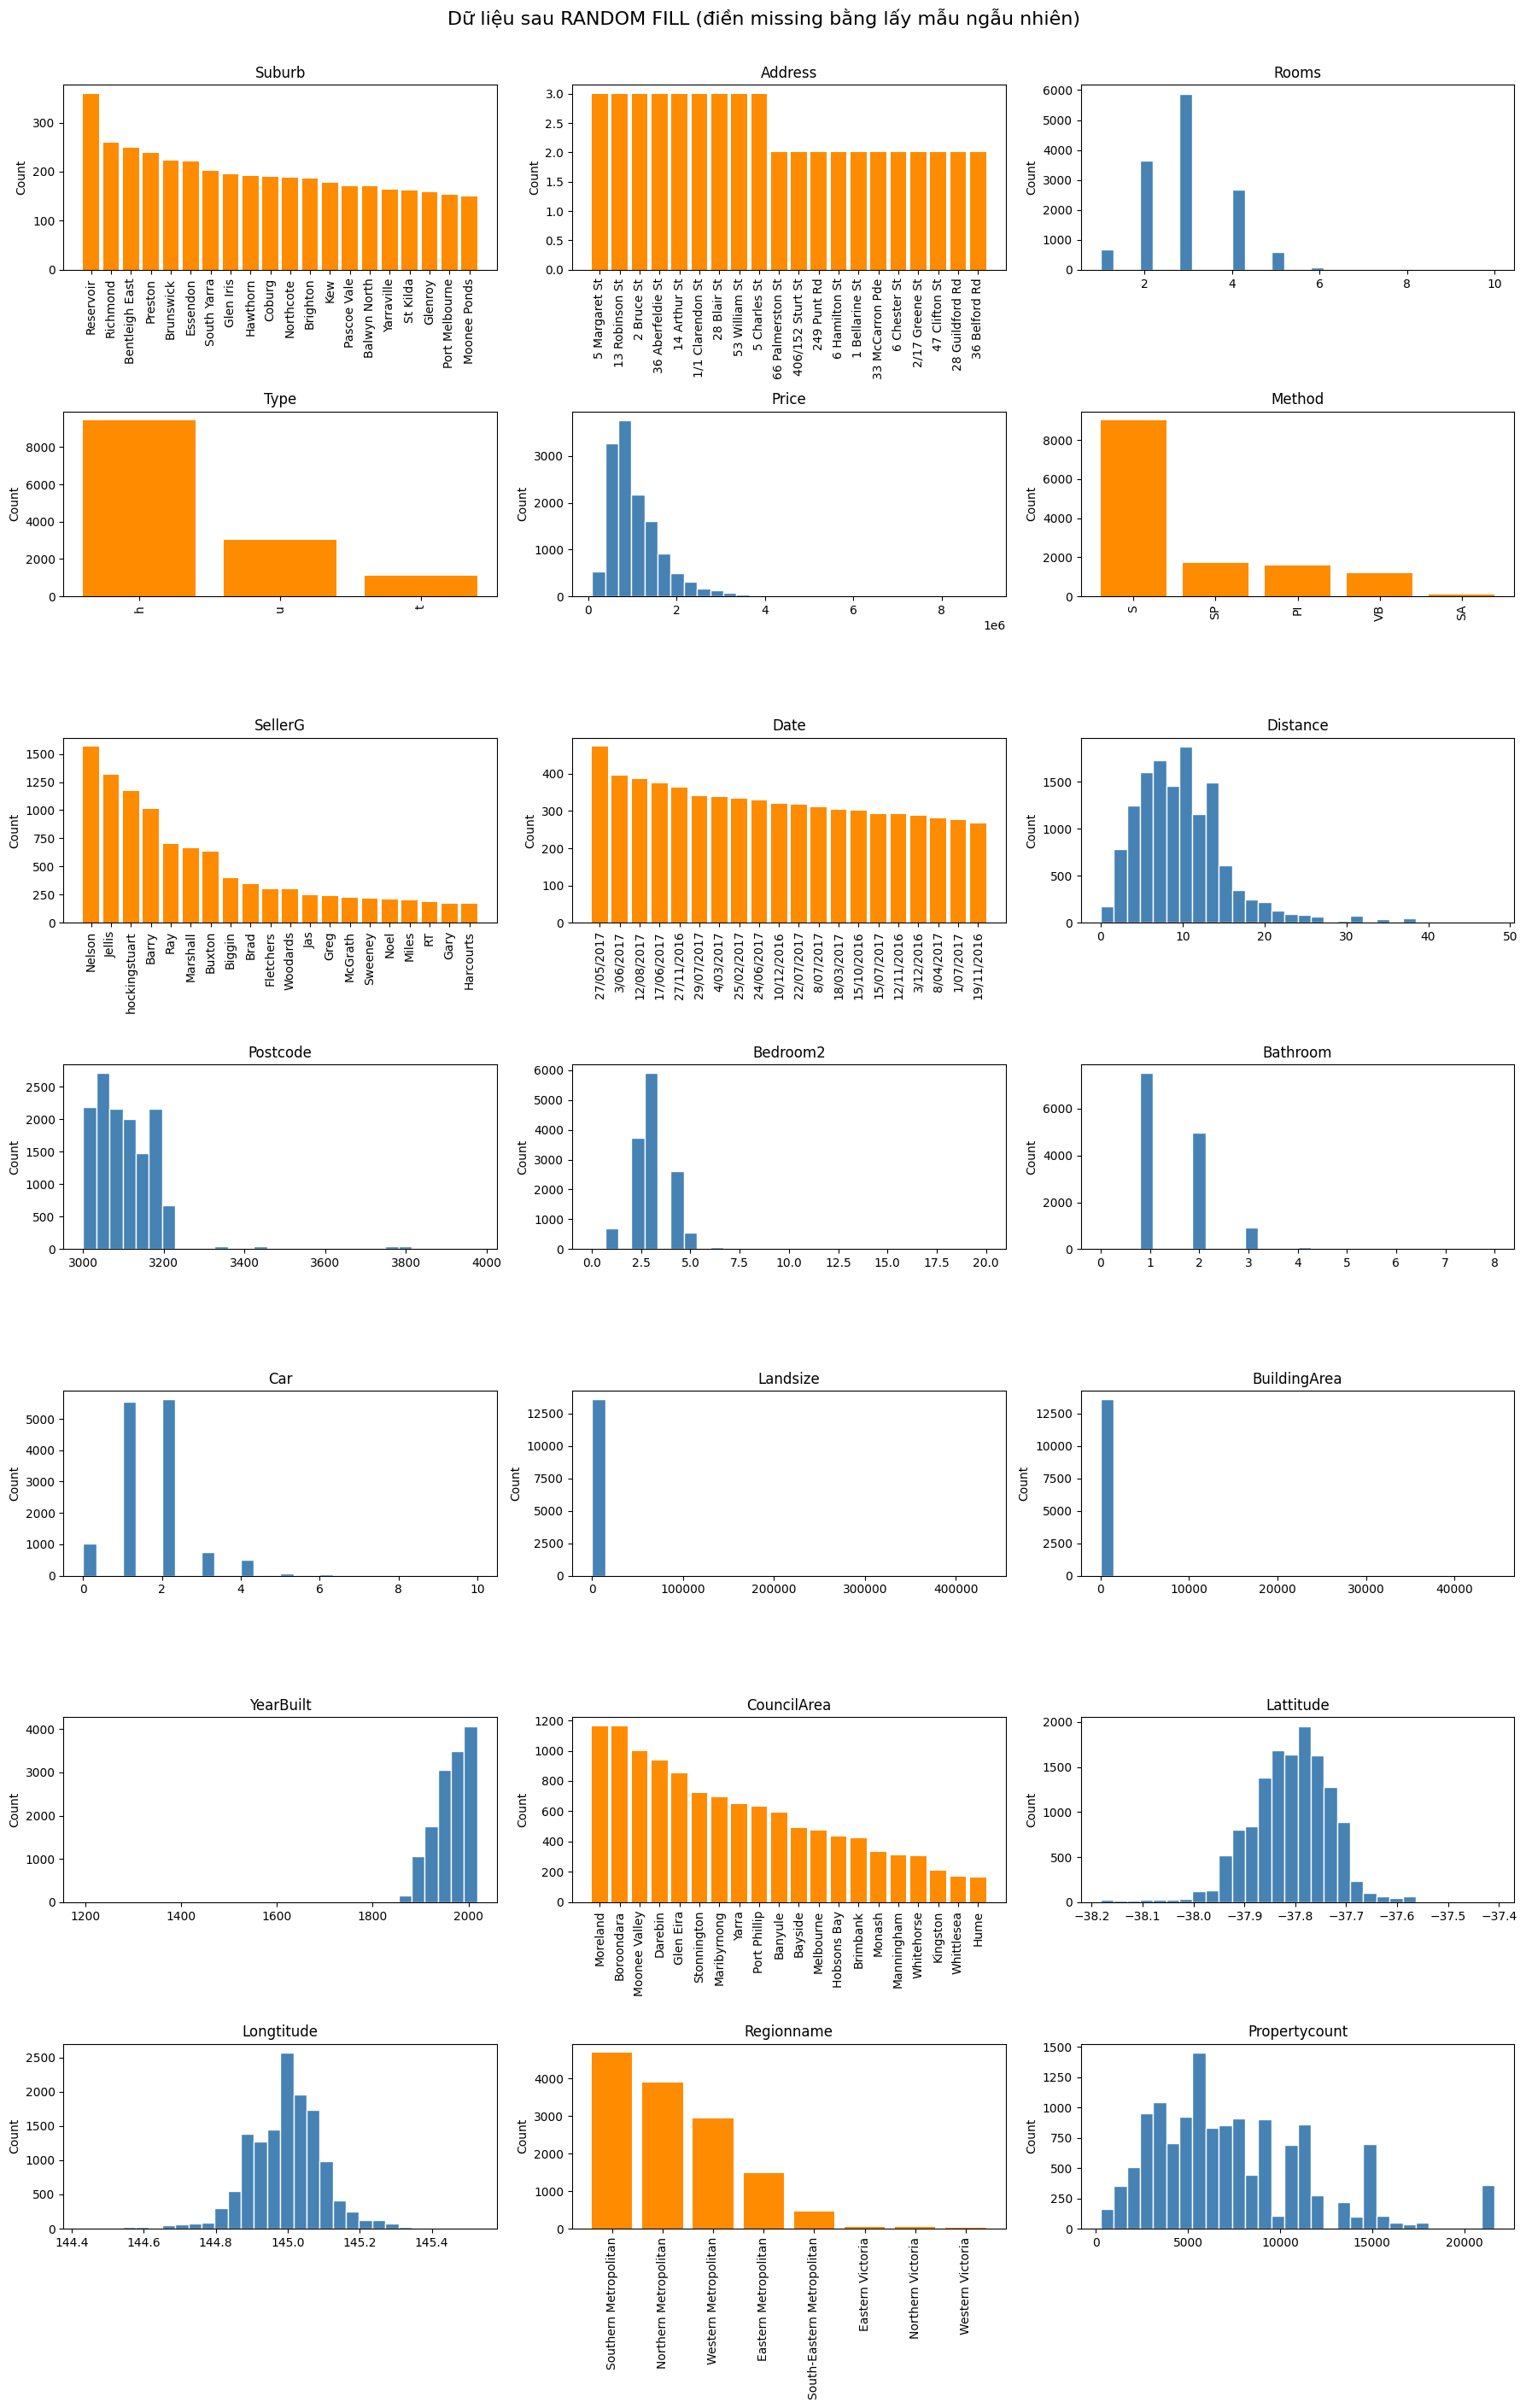

In [11]:
# ===== BẢN 2: Sau RANDOM FILL (điền missing bằng lấy mẫu ngẫu nhiên từ giá trị thật) =====
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(42)  # seed để kết quả lặp lại được

def random_fill(s):
    """Điền giá trị thiếu bằng cách lấy mẫu ngẫu nhiên từ các giá trị non-null đã có.
    Giữ được hình dạng phân phối gốc, không tạo spike giả như fillna(mean)."""
    s = s.copy()
    mask = s.isna()
    n_missing = mask.sum()
    if n_missing > 0:
        observed = s.dropna().values
        s.loc[mask] = rng.choice(observed, size=n_missing, replace=True)
    return s

# Phân loại cột: số (numeric) và phân loại (categorical)
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

cols = df.columns.tolist()
n = len(cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    if col in numeric_cols:
        # Cột số -> điền thiếu bằng random sampling rồi vẽ histogram (dạng cột)
        data = random_fill(df[col])
        ax.hist(data, bins=30, color='steelblue', edgecolor='white')
        ax.set_ylabel('Count')
    else:
        # Cột phân loại -> bar chart đếm số lượng (top 20 giá trị phổ biến nhất)
        vc = df[col].value_counts().head(20)
        ax.bar(vc.index.astype(str), vc.values, color='darkorange')
        ax.tick_params(axis='x', rotation=90)
        ax.set_ylabel('Count')
    ax.set_title(col)

# Ẩn các ô thừa
for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Dữ liệu sau RANDOM FILL (điền missing bằng lấy mẫu ngẫu nhiên)", fontsize=16, y=1.005)
plt.tight_layout()
plt.show()

> 📊 **Phân tích:** Histogram sau random fill **gần như trùng khít** bản dữ liệu thật ở mọi cột, kể cả `BuildingArea`/`YearBuilt` (đã hết missing). → random sampling **bảo toàn phân phối biên** của từng cột (đúng kỳ vọng). Nhưng đây mới chỉ là góc nhìn **đơn biến**; ảnh hưởng tới quan hệ *giữa các biến* sẽ lộ ra ở phần heatmap bên dưới.

## 8. Điền missing (cách 2) — KNN imputation

**Lý do:** KNN (`weights='distance'`) điền dựa trên các dòng tương tự nhất theo các feature khác, nên
**giữ được tương quan đa biến** (khác random sampling vốn bốc độc lập từng cột). Phải **scale
(StandardScaler) trước** vì KNN dùng khoảng cách Euclid — không scale thì Price/Landsize thang lớn sẽ át.
Tạo `df_knn` để dùng cho các bước sau.

Missing values trong các cột số sau KNN impute:
Rooms            0
Price            0
Distance         0
Postcode         0
Bedroom2         0
Bathroom         0
Car              0
Landsize         0
BuildingArea     0
YearBuilt        0
Lattitude        0
Longtitude       0
Propertycount    0
dtype: int64


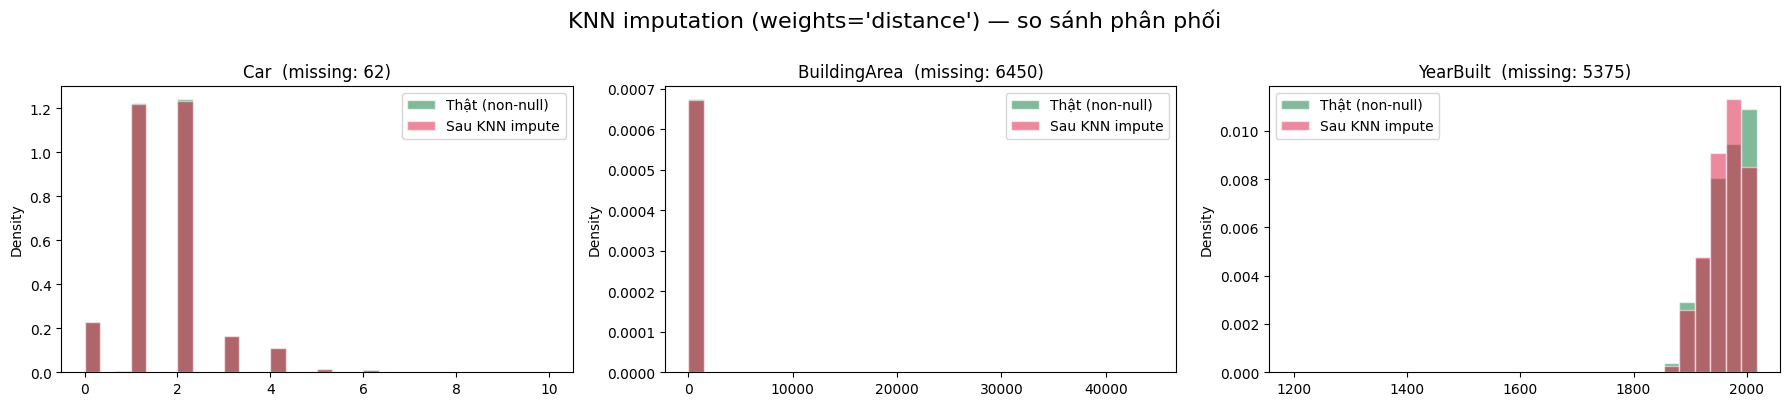

In [12]:
# ===== KNN imputation (có trọng số theo khoảng cách) cho các cột số =====
# weights='distance': láng giềng càng gần thì đóng góp càng lớn -> giữ pattern/quan hệ
# giữa các biến tự nhiên hơn so với mean/random fill.
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
X = df[numeric_cols]

# 1) Scale trước: KNN dùng khoảng cách Euclid, không scale thì Price/Landsize sẽ át hết.
#    StandardScaler của sklearn tự bỏ qua NaN khi fit và giữ nguyên NaN khi transform.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2) KNN impute trên không gian đã scale, có trọng số theo khoảng cách.
knn = KNNImputer(n_neighbors=5, weights='distance')
X_scaled_imputed = knn.fit_transform(X_scaled)

# 3) Inverse transform về thang đo gốc.
X_imputed = scaler.inverse_transform(X_scaled_imputed)

# Tạo dataframe mới: cột số đã được KNN-fill, các cột khác giữ nguyên.
df_knn = df.copy()
df_knn[numeric_cols] = pd.DataFrame(X_imputed, columns=numeric_cols, index=df.index)

# Kiểm tra: không còn missing ở các cột số
print("Missing values trong các cột số sau KNN impute:")
print(df_knn[numeric_cols].isna().sum())

# ----- Vẽ so sánh: dữ liệu thật (xanh lá) vs sau KNN impute (đỏ) cho các cột từng thiếu -----
cols_had_missing = [c for c in numeric_cols if df[c].isna().sum() > 0]

ncols = 3
nrows = int(np.ceil(len(cols_had_missing) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 4))
axes = np.array(axes).flatten()

for i, col in enumerate(cols_had_missing):
    ax = axes[i]
    n_missing = df[col].isna().sum()
    ax.hist(df[col].dropna(), bins=30, alpha=0.6, color='seagreen',
            edgecolor='white', label='Thật (non-null)', density=True)
    ax.hist(df_knn[col], bins=30, alpha=0.5, color='crimson',
            edgecolor='white', label='Sau KNN impute', density=True)
    ax.set_title(f"{col}  (missing: {n_missing})")
    ax.set_ylabel('Density')
    ax.legend()

for j in range(len(cols_had_missing), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("KNN imputation (weights='distance') — so sánh phân phối", fontsize=16, y=1.005)
plt.tight_layout()
plt.show()

> 📊 **Phân tích:** Sau KNN, **cả 13 cột số đã hết missing** (đều = 0). So phân phối thật (xanh) vs sau KNN (đỏ): `Car` trùng khít (chỉ 62 missing); `YearBuilt` giữ đúng hình dạng (đỉnh ~1950–2010), chỉ hơi dồn thêm về vùng trung tâm; `BuildingArea` bị nén do **outlier cực lớn chưa loại** (cell này chạy trên dữ liệu chưa xử lý outlier — cần lưu ý). → KNN điền mà vẫn giữ dạng phân phối, sẵn sàng cho bước so sánh tương quan.

## 9. Tương quan giữa các biến số — 3 góc nhìn

### 9a. Heatmap — dữ liệu thật

**Lý do:** Heatmap tương quan Pearson giữa các biến số trên **dữ liệu thật** (pairwise, bỏ qua missing) —
làm **mốc tham chiếu**. Đặt `Price` ở cuối hai trục để dễ đọc tương quan của target với từng feature.

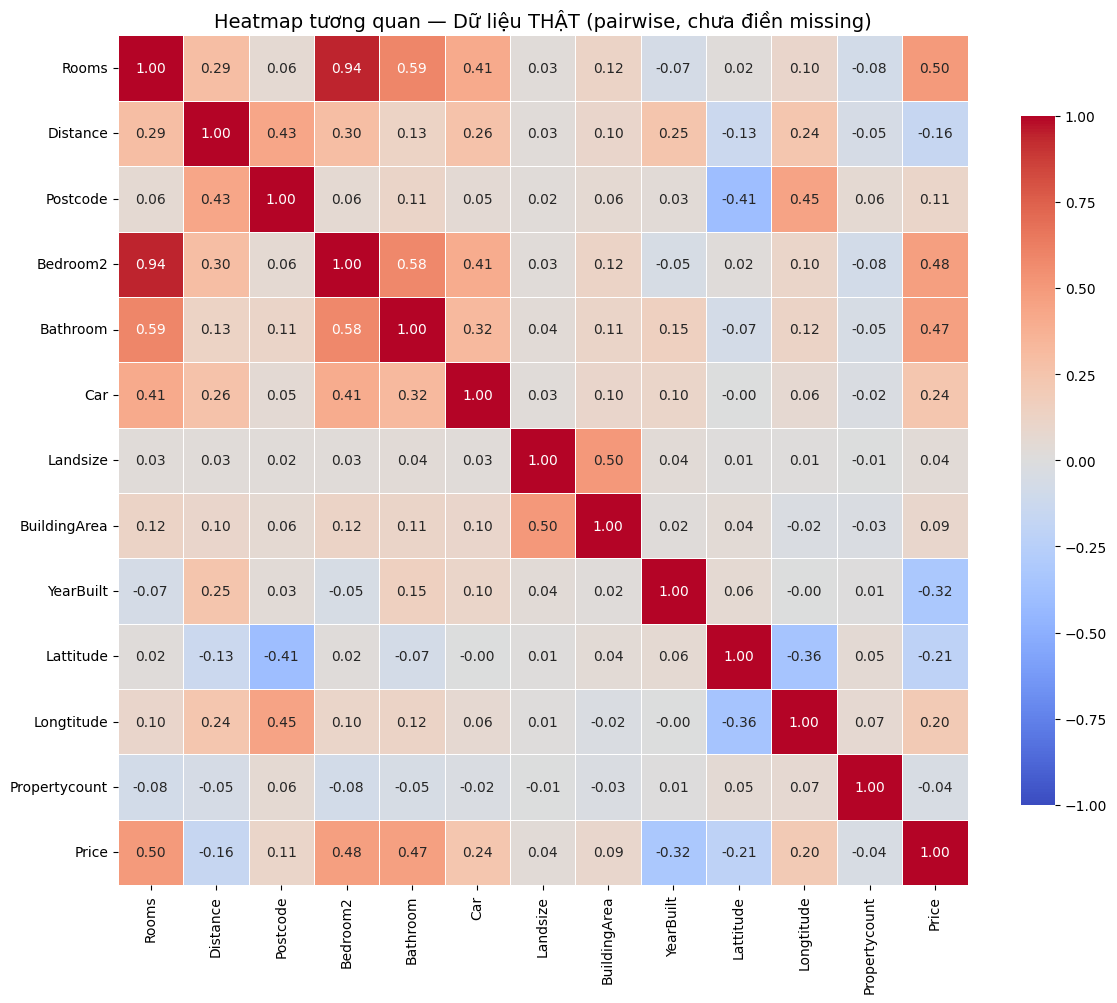

In [13]:
# ===== HEATMAP 1: Dữ liệu THẬT (tương quan pairwise, bỏ qua missing) =====
import seaborn as sns

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
# Đưa 'Price' (target) xuống cuối trên cả 2 trục cho dễ xem.
ordered_cols = [c for c in numeric_cols if c != 'Price'] + ['Price']

# df.corr() tính pairwise -> với mỗi cặp cột chỉ dùng các dòng cả 2 đều non-null.
corr_real = df[ordered_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_real, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5,
            cbar_kws={'shrink': .8})
plt.title("Heatmap tương quan — Dữ liệu THẬT (pairwise, chưa điền missing)", fontsize=14)
plt.tight_layout()
plt.show()

> 📊 **Phân tích (mốc tham chiếu):** Tương quan mạnh nhất với `Price`: **Rooms +0,50, Bedroom2 +0,48, Bathroom +0,47** — và Rooms–Bedroom2 = **0,94**, Rooms–Bathroom 0,59 → **đa cộng tuyến** trong nhóm phòng. `YearBuilt` **−0,32** (năm xây càng lớn, giá có xu hướng giảm nhẹ); vị trí: Lat −0,21, Long +0,20. Hai cột thiếu nhiều có tương quan **thật** với Price: **BuildingArea +0,091, YearBuilt −0,324** — đây là giá trị gốc để đối chiếu hai cách điền bên dưới.

### 9b. Heatmap — sau random fill

**Lý do:** Cùng heatmap nhưng trên dữ liệu **sau random fill**, để so với mốc thật: random sampling
ảnh hưởng thế nào tới cấu trúc tương quan.

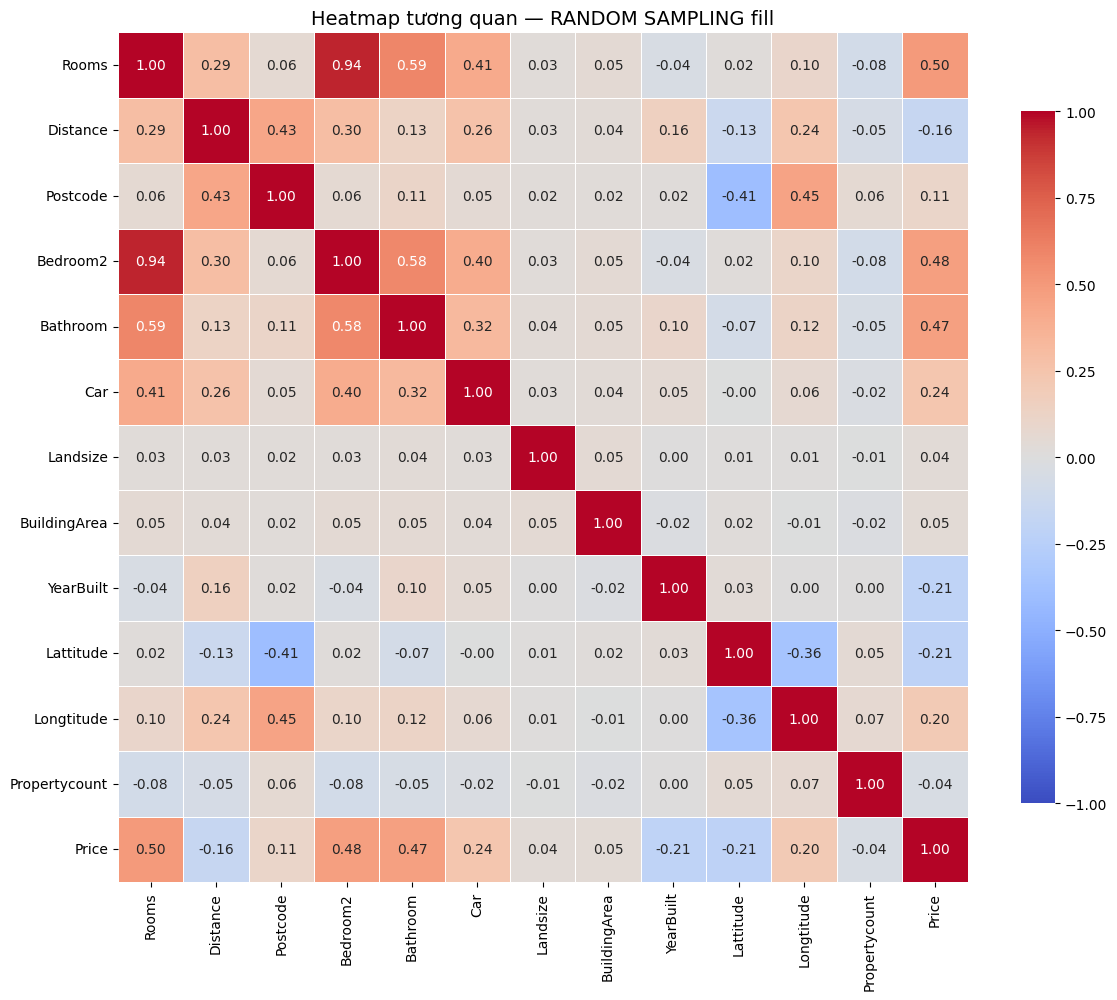

In [14]:
# ===== HEATMAP 2: Sau RANDOM SAMPLING fill =====
import seaborn as sns

rng = np.random.default_rng(42)

def random_fill(s):
    """Điền missing bằng lấy mẫu ngẫu nhiên từ các giá trị non-null đã có."""
    s = s.copy()
    mask = s.isna()
    n_missing = mask.sum()
    if n_missing > 0:
        observed = s.dropna().values
        s.loc[mask] = rng.choice(observed, size=n_missing, replace=True)
    return s

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
# Đưa 'Price' (target) xuống cuối trên cả 2 trục cho dễ xem.
ordered_cols = [c for c in numeric_cols if c != 'Price'] + ['Price']

# Áp random fill cho từng cột số -> df_random
df_random = df.copy()
for col in numeric_cols:
    df_random[col] = random_fill(df[col])

corr_random = df_random[ordered_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_random, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5,
            cbar_kws={'shrink': .8})
plt.title("Heatmap tương quan — RANDOM SAMPLING fill", fontsize=14)
plt.tight_layout()
plt.show()

> 📊 **Phân tích:** Cột **không bị điền** giữ nguyên tương quan như bản thật (Rooms 0,50, Bathroom 0,47…). Nhưng hai cột điền nhiều bị **kéo tương quan về ~0**: **BuildingArea–Price 0,091 → 0,046** (giảm ~½), **YearBuilt–Price −0,324 → −0,206**; BuildingArea–Rooms 0,124 → 0,048; BuildingArea–Bathroom 0,112 → 0,049. → random sampling **phá vỡ tương quan đa biến** vì điền độc lập với các cột khác: tốt cho trực quan đơn biến nhưng **làm loãng tín hiệu** cho mô hình.

### 9c. Heatmap — sau KNN

**Lý do:** Cùng heatmap trên dữ liệu **sau KNN impute**. So ba heatmap (thật / random / KNN) là
**bằng chứng** để chọn cách impute: cách nào giữ tương quan bám sát bản thật hơn.

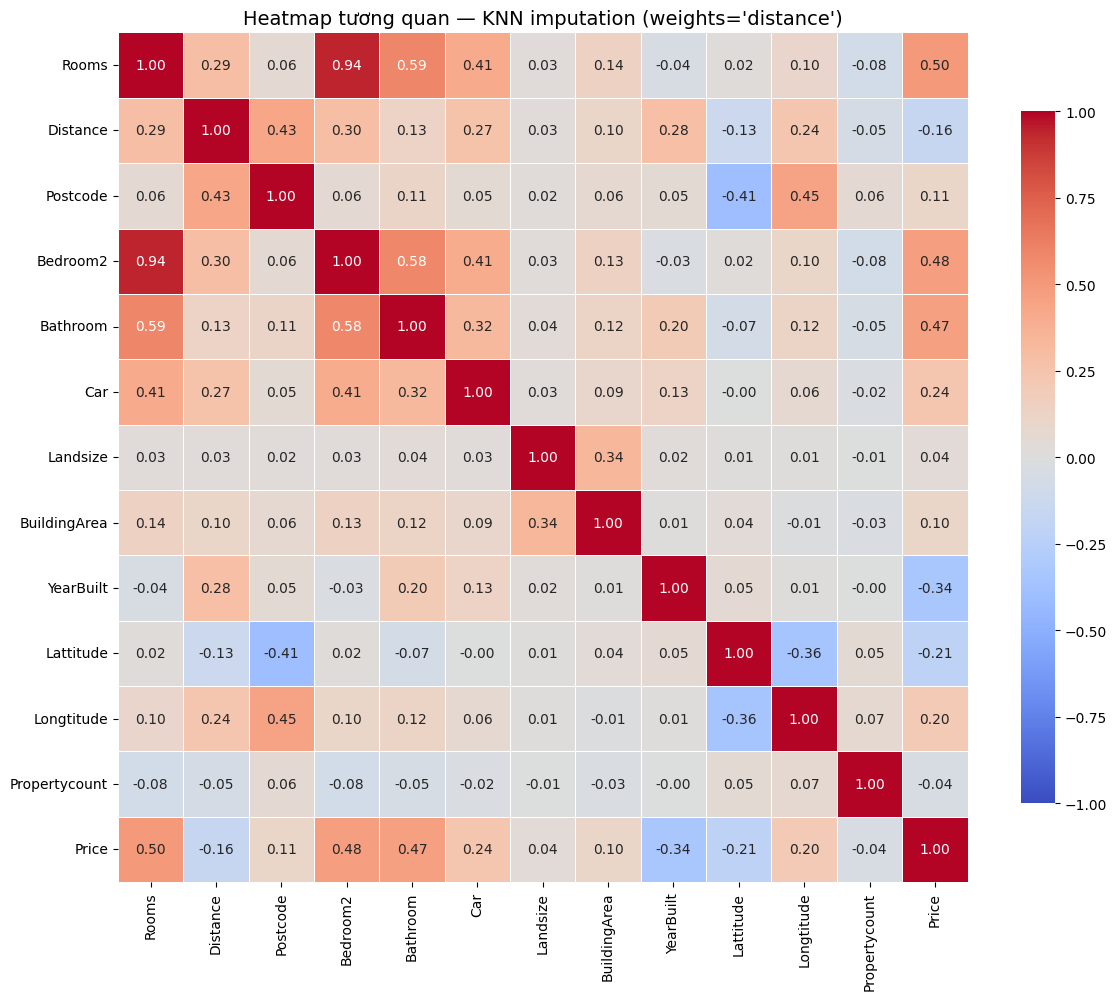

In [15]:
# ===== HEATMAP 3: Sau KNN imputation (weights='distance') =====
# Dùng df_knn đã tạo ở cell KNN imputation phía trên.
import seaborn as sns

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
# Đưa 'Price' (target) xuống cuối trên cả 2 trục cho dễ xem.
ordered_cols = [c for c in numeric_cols if c != 'Price'] + ['Price']

corr_knn = df_knn[ordered_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_knn, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5,
            cbar_kws={'shrink': .8})
plt.title("Heatmap tương quan — KNN imputation (weights='distance')", fontsize=14)
plt.tight_layout()
plt.show()

> 📊 **Phân tích (căn cứ chọn KNN):** KNN giữ tương quan của cột điền **bám sát bản thật**: **BuildingArea–Price 0,105** (thật 0,091), **YearBuilt–Price −0,336** (thật −0,324), BuildingArea–Rooms 0,136 (thật 0,124), BuildingArea–Bathroom 0,122 (thật 0,112) — khác hẳn random (0,046 / −0,206 / 0,048 / 0,049, sụp về 0). → **Kết luận: chọn KNN** để mang dữ liệu đi mô hình vì bảo toàn pattern/coefficient đa biến; random sampling chỉ dùng cho trực quan hoá phân phối đơn biến.

## 10. Ảnh hưởng của mọi feature lên Price

**Lý do:** Heatmap Pearson chỉ đo được biến số. Để xếp hạng ảnh hưởng của **cả** biến phân loại lên Price,
dùng |Pearson| cho biến số và **correlation ratio η** cho biến phân loại (η ∈ [0,1], đo phần dao động của
Price được giải thích bởi việc thuộc nhóm category nào). Lưu ý η không dấu và **dễ bị thổi phồng bởi
cardinality cao** → cần đối chiếu với cột `n_unique`.

          feature  strength                 type  n_unique
0         Address  0.996781         category (η)     13378
1          Suburb  0.559646         category (η)       314
2           Rooms  0.496634  numeric (|Pearson|)         9
3         SellerG  0.478232         category (η)       268
4        Bedroom2  0.475951  numeric (|Pearson|)        12
5        Bathroom  0.467038  numeric (|Pearson|)         9
6     CouncilArea  0.450977         category (η)        33
7            Type  0.414587         category (η)         3
8      Regionname  0.357660         category (η)         8
9       YearBuilt  0.335831  numeric (|Pearson|)      5484
10            Car  0.237264  numeric (|Pearson|)        71
11      Lattitude  0.212934  numeric (|Pearson|)      6503
12     Longtitude  0.203656  numeric (|Pearson|)      7063
13           Date  0.163071         category (η)        58
14       Distance  0.162522  numeric (|Pearson|)       202
15         Method  0.111624         category (η)        

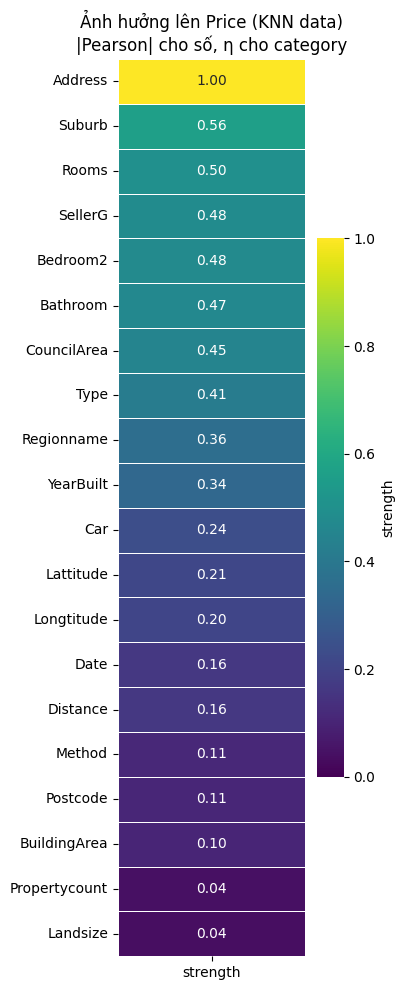

In [16]:
# ===== Độ ảnh hưởng lên Price trên DỮ LIỆU KNN: số (|Pearson|) + category (η) =====
# Dùng df_knn (cột số đã KNN-impute; cột category giữ nguyên dạng gốc).
import seaborn as sns

def correlation_ratio(categories, values):
    """Correlation ratio η giữa biến category và biến số.
    η = sqrt( SS_between_groups / SS_total ), nằm trong [0, 1].
    Đo phần dao động của 'values' được giải thích bởi việc thuộc nhóm category nào."""
    tmp = pd.DataFrame({'cat': categories, 'val': values}).dropna()
    vals = tmp['val'].values
    cats = tmp['cat'].values
    ss_total = ((vals - vals.mean()) ** 2).sum()
    if ss_total == 0:
        return 0.0
    ss_between = 0.0
    for c in pd.unique(cats):
        group = vals[cats == c]
        ss_between += len(group) * (group.mean() - vals.mean()) ** 2
    return np.sqrt(ss_between / ss_total)

numeric_cols = df_knn.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df_knn.select_dtypes(exclude=np.number).columns.tolist()

records = []

# Cột số: |Pearson| với Price (trị tuyệt đối để so độ mạnh, bỏ chính Price).
for col in numeric_cols:
    if col == 'Price':
        continue
    r = df_knn[[col, 'Price']].corr().iloc[0, 1]
    records.append({'feature': col, 'strength': abs(r),
                    'type': 'numeric (|Pearson|)', 'n_unique': df_knn[col].nunique()})

# Cột category: correlation ratio η với Price.
for col in categorical_cols:
    eta = correlation_ratio(df_knn[col], df_knn['Price'])
    records.append({'feature': col, 'strength': eta,
                    'type': 'category (η)', 'n_unique': df_knn[col].nunique()})

assoc = pd.DataFrame(records).sort_values('strength', ascending=False).reset_index(drop=True)
print(assoc)

# ----- Heatmap 1 cột: độ ảnh hưởng của mọi feature lên Price -----
heat = assoc.set_index('feature')[['strength']]
plt.figure(figsize=(4, 10))
sns.heatmap(heat, annot=True, fmt='.2f', cmap='viridis', vmin=0, vmax=1,
            linewidths=.5, cbar_kws={'shrink': .6, 'label': 'strength'})
plt.title("Ảnh hưởng lên Price (KNN data)\n|Pearson| cho số, η cho category", fontsize=12)
plt.ylabel("")
plt.tight_layout()
plt.show()

> 📊 **Phân tích:** Xếp hạng ảnh hưởng lên Price (|Pearson| cho biến số, η cho biến phân loại). **Cảnh báo cardinality:** `Address` η=**0,997** nhưng n_unique=13.378 → **ảo** do cardinality cực cao (mỗi nhóm vài mẫu, overfit), không phải tín hiệu thật; `Suburb` η=0,560 (314) và `SellerG` η=0,478 (268) cũng bị thổi phồng phần nào. Tín hiệu **đáng tin** (cardinality thấp): **`Type` η=0,415 (3)**, `Regionname` η=0,358 (8), `CouncilArea` η=0,451 (33). Phía biến số mạnh nhất: **Rooms 0,497, Bedroom2 0,476, Bathroom 0,467**. `Landsize` (0,038) và `BuildingArea` (0,105) yếu **vì cell này dùng `df_knn` chưa loại outlier** (outlier nén Pearson) — sau khi loại cực trị + log thì quan hệ sẽ rõ hơn.

### 10b. Ảnh hưởng lên Price — trên dữ liệu đã loại cực trị + log

**Lý do:** Bảng xếp hạng ở mục 10 chạy trên `df_knn` **chưa xử lý outlier**, nên |Pearson| của
`Landsize`/`BuildingArea` bị outlier nén xuống thấp giả. Tính lại trên `df_trans` (đã loại cực trị +
`log1p`), thay hai cột raw bằng bản `_log`, để thấy quan hệ với Price **trung thực hơn**.

             feature  strength                 type  n_unique
0            Address  0.996781         category (η)     13378
1             Suburb  0.559646         category (η)       314
2              Rooms  0.496634  numeric (|Pearson|)         9
3   BuildingArea_log  0.495807  numeric (|Pearson|)       537
4            SellerG  0.478232         category (η)       268
5           Bedroom2  0.475951  numeric (|Pearson|)        12
6           Bathroom  0.467038  numeric (|Pearson|)         9
7        CouncilArea  0.450977         category (η)        33
8               Type  0.414587         category (η)         3
9         Regionname  0.357660         category (η)         8
10         YearBuilt  0.331828  numeric (|Pearson|)       143
11               Car  0.238979  numeric (|Pearson|)        11
12         Lattitude  0.212934  numeric (|Pearson|)      6503
13        Longtitude  0.203656  numeric (|Pearson|)      7063
14      Landsize_log  0.191798  numeric (|Pearson|)      1335
15      

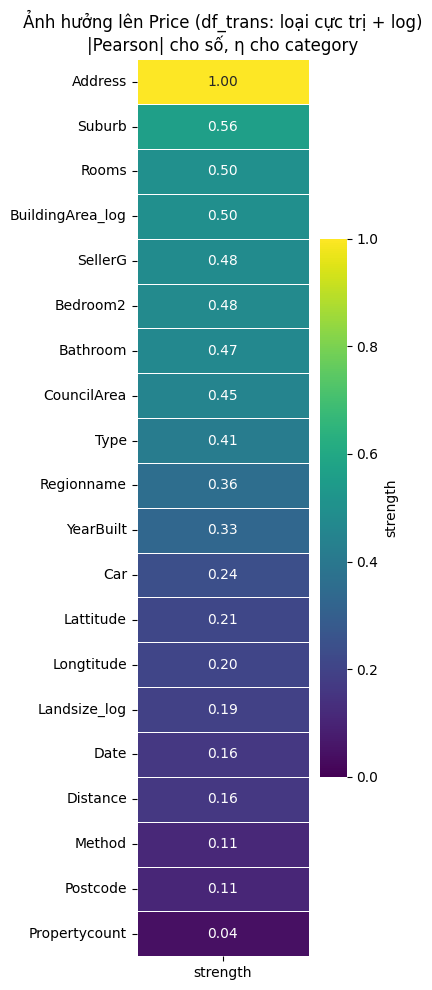

In [17]:
# ===== Xếp hạng ảnh hưởng lên Price — DỮ LIỆU ĐÃ LOẠI CỰC TRỊ + LOG (df_trans) =====
# Dùng df_trans (Landsize/BuildingArea đã loại cực trị + log1p) thay vì df_knn chưa xử lý outlier.
import seaborn as sns

num_use = [c for c in df_trans.select_dtypes(include=np.number).columns
           if c not in ('Price', 'Landsize', 'BuildingArea')]  # đã gồm Landsize_log, BuildingArea_log
cat_cols = df_trans.select_dtypes(exclude=np.number).columns.tolist()


def correlation_ratio(categories, values):
    tmp = pd.DataFrame({'cat': categories, 'val': values}).dropna()
    vals = tmp['val'].values
    cats = tmp['cat'].values
    ss_total = ((vals - vals.mean()) ** 2).sum()
    if ss_total == 0:
        return 0.0
    ss_between = 0.0
    for c in pd.unique(cats):
        g = vals[cats == c]
        ss_between += len(g) * (g.mean() - vals.mean()) ** 2
    return np.sqrt(ss_between / ss_total)


records = []
for col in num_use:
    r = df_trans[[col, 'Price']].corr().iloc[0, 1]
    records.append({'feature': col, 'strength': abs(r),
                    'type': 'numeric (|Pearson|)', 'n_unique': df_trans[col].nunique()})
for col in cat_cols:
    eta = correlation_ratio(df_trans[col], df_trans['Price'])
    records.append({'feature': col, 'strength': eta,
                    'type': 'category (η)', 'n_unique': df_trans[col].nunique()})

assoc2 = pd.DataFrame(records).sort_values('strength', ascending=False).reset_index(drop=True)
print(assoc2)

heat = assoc2.set_index('feature')[['strength']]
plt.figure(figsize=(4, 10))
sns.heatmap(heat, annot=True, fmt='.2f', cmap='viridis', vmin=0, vmax=1,
            linewidths=.5, cbar_kws={'shrink': .6, 'label': 'strength'})
plt.title("Ảnh hưởng lên Price (df_trans: loại cực trị + log)\n|Pearson| cho số, η cho category", fontsize=12)
plt.ylabel("")
plt.tight_layout()
plt.show()

> 📊 **Phân tích:** Sau khi loại cực trị + log, quan hệ với Price **trung thực hơn hẳn**: **`BuildingArea_log` |Pearson| = 0,496** — vọt từ gần đáy (0,105 trên `df_knn` raw) lên **top-3**, gần ngang `Rooms` (0,497); **`Landsize_log` = 0,192** (từ 0,038). → diện tích xây dựng thực ra là một trong những yếu tố **mạnh nhất** quyết định giá, trước đó bị **outlier che lấp**. Các tín hiệu category đáng tin vẫn giữ nguyên (`Type` 0,415, `CouncilArea` 0,451); cảnh báo η ảo của `Address`/`Suburb`/`SellerG` vẫn áp dụng.

## 11. Lưu dữ liệu đã xử lý ra CSV

**Lý do:** Gộp hai nhánh chỉnh sửa thành **một bộ dữ liệu sẵn sàng cho model**: lấy `df_trans`
(đã loại cực trị + log, bỏ `Landsize`/`BuildingArea` raw) rồi **KNN-impute** phần còn thiếu
(cách điền đã chọn ở mục 8), và điền `CouncilArea` thiếu bằng `'Unknown'`. Kết quả không còn
missing, lưu ra `melb_data_processed.csv`.

In [18]:
# ===== Gộp xử lý + lưu dữ liệu đã xử lý =====
# df_trans: đã loại cực trị + log (cell mục 6). Bỏ Landsize/BuildingArea raw, giữ bản _log.
df_processed = df_trans.drop(columns=['Landsize', 'BuildingArea']).copy()

# KNN-impute các cột số còn thiếu (StandardScaler + KNNImputer đã import ở mục 8)
num_cols = df_processed.select_dtypes(include=np.number).columns.tolist()
scaler = StandardScaler()
Xs = scaler.fit_transform(df_processed[num_cols])
Xi = KNNImputer(n_neighbors=5, weights='distance').fit_transform(Xs)
df_processed[num_cols] = pd.DataFrame(scaler.inverse_transform(Xi),
                                      columns=num_cols, index=df_processed.index)

# Category còn thiếu (CouncilArea) -> 'Unknown'
df_processed['CouncilArea'] = df_processed['CouncilArea'].fillna('Unknown')

# Lưu (trên Colab sẽ lưu vào thư mục làm việc hiện tại trên Drive)
df_processed.to_csv('melb_data_processed.csv', index=False)
print('Đã lưu melb_data_processed.csv |', df_processed.shape,
      '| tổng missing:', int(df_processed.isna().sum().sum()))
df_processed.head()

Đã lưu melb_data_processed.csv | (13580, 21) | tổng missing: 0


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Landsize_log,BuildingArea_log
0,Abbotsford,85 Turner St,2.0,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,1903.773355,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0,5.313206,4.664207
1,Abbotsford,25 Bloomburg St,2.0,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,1900.000000,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0,5.056246,4.382027
2,Abbotsford,5 Charles St,3.0,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,1900.000000,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0,4.905275,5.017280
3,Abbotsford,40 Federation La,3.0,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,1992.072826,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0,4.553877,4.651626
4,Abbotsford,55a Park St,4.0,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,2014.000000,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0,4.795791,4.962845


> 💾 **Kết quả:** `melb_data_processed.csv` — **13.580 dòng × 21 cột, 0 missing**. Đã thay `Landsize`/`BuildingArea` bằng bản log, các cột số thiếu được KNN điền, `CouncilArea` thiếu → `'Unknown'`.
>
> ⚠️ **Lưu ý leakage:** bộ này impute trên toàn bộ dữ liệu (gồm cả `Price`). Khi train model thật nên fit imputer **chỉ trên tập train** (trong `Pipeline`) để tránh rò rỉ.